# Notebook 02 — Survival Analysis
## TCGA Lung Adenocarcinoma

Building on the EDA from notebook 01. Three approaches:

1. **Kaplan-Meier**: visualise survival probability over time by group
2. **Cox Proportional Hazards**: quantify the effect of each mutation on mortality risk
3. **XGBoost + SHAP**: predict 24-month mortality and explain which features drive it

**Main question**: do KRAS co-mutation subtypes (with STK11 or KEAP1) show significantly worse survival than KRAS alone?

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from sklearn.preprocessing import LabelEncoder

import shap

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
})

print("All imports successful")

## 1. Load data

Key columns needed from Notebook 01:
- `OS_MONTHS`: how long the patient was followed
- `OS_EVENT`: 1 = died, 0 = censored (still alive at study end, or lost to follow-up)
- `KRAS`, `STK11`, `KEAP1`: mutation flags (1 = mutated)
- `AGE`, `STAGE_NUM`: clinical covariates for the Cox model

**On censoring**: censored means we know the patient survived *at least* X months but don't know what happened after. KM handles this by removing them from the risk set at their last known time point rather than counting them as deaths.

In [14]:
df = pd.read_csv('../data/tcga_clean.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nSurvival data check:")
print(f"  Deceased        : {df['OS_EVENT'].sum()}")
print(f"  Censored        : {(df['OS_EVENT']==0).sum()}")
print(f"  Median follow-up: {df['OS_MONTHS'].median():.1f} months")

print(f"\nMutation prevalence:")
for gene in ['KRAS','STK11','KEAP1']:
    n = df[gene].sum()
    pct = n/len(df)*100
    print(f"  {gene:8s}: {n:3.0f} patients ({pct:.1f}%)")

Dataset shape: (566, 44)

Survival data check:
  Deceased        : 186
  Censored        : 380
  Median follow-up: 21.5 months

Mutation prevalence:
  KRAS    : 168 patients (29.7%)
  STK11   :  77 patients (13.6%)
  KEAP1   : 104 patients (18.4%)


## 2. Kaplan-Meier curves

Survival probability over time, split by KRAS mutation status and co-mutation subtype.

Using 505 patients with complete survival data (dropped 61 rows with NaNs)


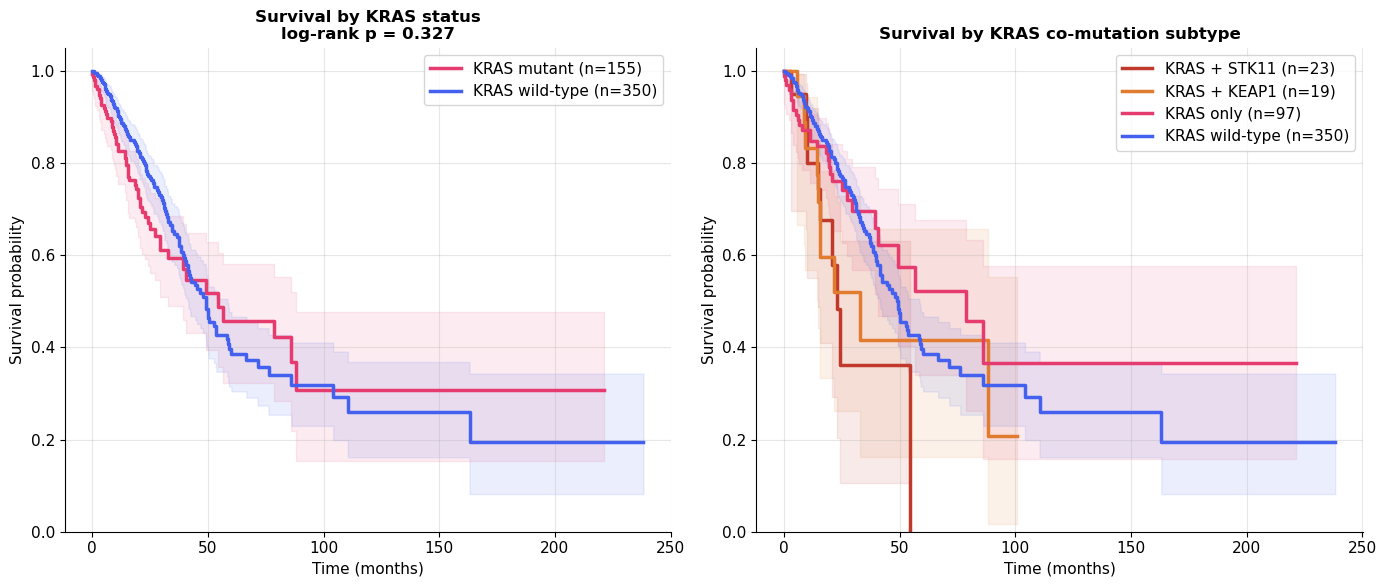

Saved to figures/km_kras_subtypes.png


In [56]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Drop rows with missing survival data before fitting KM
df_surv = df.dropna(subset=['OS_MONTHS', 'OS_EVENT'])
print(f"Using {len(df_surv)} patients with complete survival data (dropped {len(df) - len(df_surv)} rows with NaNs)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: KM by KRAS status
ax = axes[0]
kmf = KaplanMeierFitter()

groups = {
    'KRAS mutant'   : df_surv[df_surv['KRAS'] == 1],
    'KRAS wild-type': df_surv[df_surv['KRAS'] == 0],
}
colors = ['#E63B6F', '#4361EE']

for (label, group), color in zip(groups.items(), colors):
    kmf.fit(
        group['OS_MONTHS'],
        event_observed=group['OS_EVENT'],
        label=f"{label} (n={len(group)})"
    )
    kmf.plot_survival_function(ax=ax, color=color, lw=2.5,
                                ci_show=True, ci_alpha=0.1)

results = logrank_test(
    groups['KRAS mutant']['OS_MONTHS'],
    groups['KRAS wild-type']['OS_MONTHS'],
    event_observed_A=groups['KRAS mutant']['OS_EVENT'],
    event_observed_B=groups['KRAS wild-type']['OS_EVENT'],
)
ax.set_title(f'Survival by KRAS status\nlog-rank p = {results.p_value:.3f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Time (months)')
ax.set_ylabel('Survival probability')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# Right: KM by KRAS co-mutation subtype
ax = axes[1]

subtypes = {
    'KRAS + STK11'  : df_surv[(df_surv['KRAS']==1) & (df_surv['STK11']==1) & (df_surv['KEAP1']==0)],
    'KRAS + KEAP1'  : df_surv[(df_surv['KRAS']==1) & (df_surv['KEAP1']==1) & (df_surv['STK11']==0)],
    'KRAS only'     : df_surv[(df_surv['KRAS']==1) & (df_surv['STK11']==0) & (df_surv['KEAP1']==0)],
    'KRAS wild-type': df_surv[df_surv['KRAS']==0],
}
colors = ['#C0392B','#E07B30','#E63B6F','#4361EE']

for (label, group), color in zip(subtypes.items(), colors):
    if len(group) < 5:
        print(f"Warning: {label} only has {len(group)} patients, skipping")
        continue
    kmf.fit(
        group['OS_MONTHS'],
        event_observed=group['OS_EVENT'],
        label=f"{label} (n={len(group)})"
    )
    kmf.plot_survival_function(ax=ax, color=color, lw=2.5,
                                ci_show=True, ci_alpha=0.1)

ax.set_title('Survival by KRAS co-mutation subtype',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Time (months)')
ax.set_ylabel('Survival probability')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/km_kras_subtypes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to figures/km_kras_subtypes.png")

**Left panel — KRAS vs wild-type (log-rank p = 0.327)**: not significant. The curves are almost identical and even cross around month 50, meaning KRAS mutant doesn't show worse survival than wild-type

**Right panel — KRAS subtypes**: KRAS+STK11 (n=23) drops the fastest and reaches 0 by ~month 60, the worst early survival of all groups. KRAS+KEAP1 (n=19) also declines quickly early on. However, both groups are small (n<25) so the confidence intervals are very wide and we should be cautious about over-interpreting the curves. KRAS wild-type shows the best long-term survival, and KRAS only tracks close to it, reinforcing that KRAS mutation alone isn't the issue.

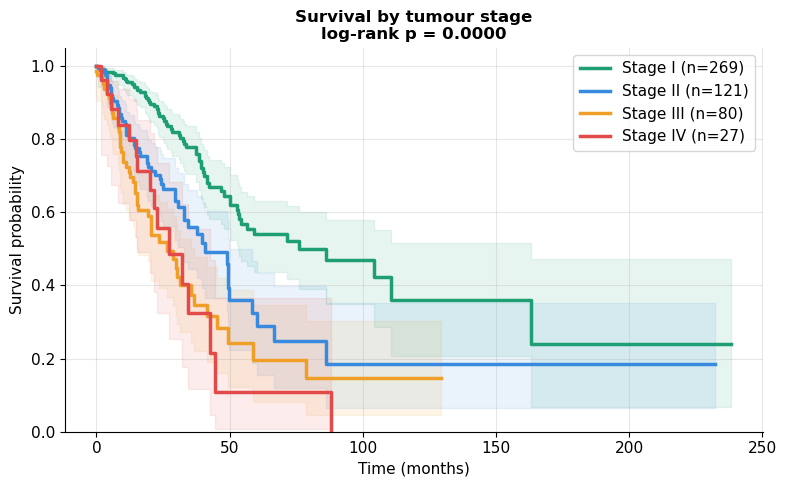

Log-rank p-value (across all stages): 1.95e-12


In [69]:
df_stage = df_surv.dropna(subset=['STAGE_NUM'])

fig, ax = plt.subplots(figsize=(8, 5))
kmf = KaplanMeierFitter()

stage_labels = {1: 'Stage I', 2: 'Stage II', 3: 'Stage III', 4: 'Stage IV'}
colors = ['#1D9E75', '#378ADD', '#EF9F27', '#E24B4A']

for stage_num, color in zip([1, 2, 3, 4], colors):
    group = df_stage[df_stage['STAGE_NUM'] == stage_num]
    if len(group) < 5:
        continue
    kmf.fit(group['OS_MONTHS'], event_observed=group['OS_EVENT'],
            label=f"{stage_labels[stage_num]} (n={len(group)})")
    kmf.plot_survival_function(ax=ax, color=color, lw=2.5, ci_show=True, ci_alpha=0.1)

# Multivariate log-rank test across all stages
results_stage = multivariate_logrank_test(
    df_stage['OS_MONTHS'],
    df_stage['STAGE_NUM'],
    event_observed=df_stage['OS_EVENT']
)

ax.set_title(f'Survival by tumour stage\nlog-rank p = {results_stage.p_value:.4f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Time (months)')
ax.set_ylabel('Survival probability')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/km_by_stage.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Log-rank p-value (across all stages): {results_stage.p_value:.2e}")

Stage I (n=269) shows clearly the best survival, Stage IV (n=27) the worst, with I > II > III > IV. Stage IV drops steeply and approaches 0 by ~month 90. The wide CI for Stage IV reflects the small group size (n=27), consistent with the TCGA bias toward early-stage disease noted in notebook 01

## 3. Cox Proportional Hazards model

KM curves show whether survival differs between groups, but they can't tell us if the effect of KRAS is independent of age or stage 

Cox PH models the instantaneous risk of dying (the "hazard") as a function of multiple variables simultaneously:

`h(t) = h₀(t) × exp(β₁·KRAS + β₂·STK11 + β₃·KEAP1 + β₄·AGE + β₅·STAGE_NUM)`

The key output is the **hazard ratio** = exp(β). If HR = 1.5 for STK11, that means STK11-mutant patients have a 50% higher death rate at any point in time, after controlling for the other variables.

The model assumes the hazard ratio is **constant over time** meaning the survival curves don't cross

In [70]:
cox_features = ['KRAS', 'STK11', 'KEAP1', 'AGE', 'STAGE_NUM']
df_cox = df_surv[cox_features + ['OS_MONTHS', 'OS_EVENT']].dropna()

print(f"Cox model: {len(df_cox)} patients with complete data")
print(f"(dropped {len(df_surv) - len(df_cox)} with missing AGE or STAGE_NUM)\n")

cph = CoxPHFitter()
cph.fit(df_cox, duration_col='OS_MONTHS', event_col='OS_EVENT')
cph.print_summary(decimals=3)

Cox model: 487 patients with complete data
(dropped 18 with missing AGE or STAGE_NUM)



<lifelines.CoxPHFitter: fitted with 487 total observations, 310 right-censored observations>
             duration col = 'OS_MONTHS'
                event col = 'OS_EVENT'
      baseline estimation = breslow
   number of observations = 487
number of events observed = 177
   partial log-likelihood = -909.000
         time fit was run = 2026-06-19 21:49:50 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
KRAS      0.137     1.147     0.167          -0.190           0.464               0.827               1.591
STK11     0.640     1.896     0.204           0.240           1.040               1.271               2.829
KEAP1     0.043     1.044     0.181          -0.312           0.397               0.732               1.487
AGE       0.011     1.011     0.008          -0.004           0.027               0.996               1.027
STAGE_NUM 0.501     1.650     0.073           0.358           0.644               1.430               1.904

           cmp to     z       p  -log2(p)
covariate                                
KRAS        0.000 0.823   0.410     1.285
STK11       0.000 3.136   0.002     9.192
KEAP1       0.000 0.236   0.813     0.298
AGE         0.000 1.430   0.153     2.712
STAGE_NUM   0.000 6.855 <0.0005    37.028
---
Concordance = 0.685
Partial AIC = 1828.001
log-likelihood ratio test = 53.751 on 5 df
-log2(p) of ll-ratio test = 31.982

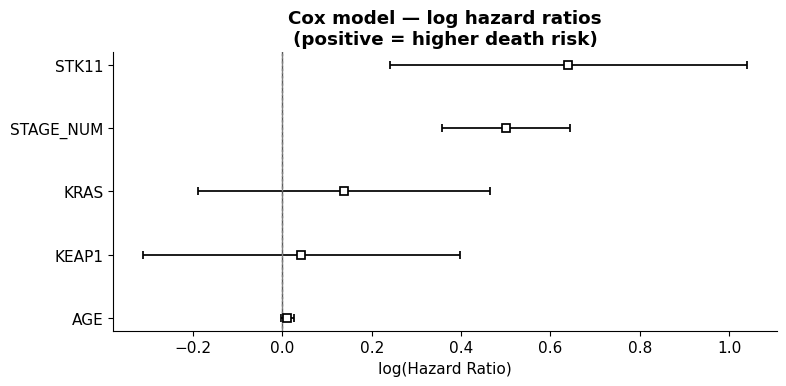

-- Hazard Ratios (exp(coef)) --
  KRAS        : HR = 1.15  (95% CI: 0.83–1.59)
  STK11       : HR = 1.90  (95% CI: 1.27–2.83)
  KEAP1       : HR = 1.04  (95% CI: 0.73–1.49)
  AGE         : HR = 1.01  (95% CI: 1.00–1.03)
  STAGE_NUM   : HR = 1.65  (95% CI: 1.43–1.90)


In [75]:
# Plot hazard ratios with confidence intervals
fig, ax = plt.subplots(figsize=(8, 4))
cph.plot(ax=ax)
ax.axvline(0, color='grey', linestyle='--', lw=1)
ax.set_title('Cox model — log hazard ratios\n(positive = higher death risk)', fontweight='bold')
ax.set_xlabel('log(Hazard Ratio)')
plt.tight_layout()
plt.savefig('../figures/cox_hr.png', dpi=150, bbox_inches='tight')
plt.show()

# Print HRs in a readable way
print("-- Hazard Ratios (exp(coef)) --")
hr = np.exp(cph.params_)
ci = np.exp(cph.confidence_intervals_)
for var in cox_features:
    print(f"  {var:12s}: HR = {hr[var]:.2f}  (95% CI: {ci.loc[var,'95% lower-bound']:.2f}–{ci.loc[var,'95% upper-bound']:.2f})")

- **STAGE_NUM** (HR = 1.65, p < 0.0005): strongest predictor: each stage increase raises death risk by 65%
- **STK11** (HR = 1.90, p = 0.002): significant independent predictor. Patients with STK11 mutation have ~90% higher death risk, after controlling for stage and age. Since most STK11-mutant patients in this cohort also carry KRAS, this reflects the KRAS+STK11 subtype identified in the KM analysis
- **KRAS** (HR = 1.15, p = 0.41): not significant on its own. Consistent with the hypothesis that KRAS alone isn't the problem. It's the co-mutation with STK11 or KEAP1.
- **KEAP1** (HR = 1.04, p = 0.81): not significant. Could be underpowered (n=104), or KEAP1 may not add independent prognostic value beyond stage in this cohort.
- **Concordance = 0.685**: equivalent to AUC for survival models. Reasonable for genomic data

## 4. XGBoost — predicting 24-month mortality

Cox tells us about risk over the full follow-up period. Here I want to answer: **can we predict whether a patient will die within 24 months?** That's clinically actionable because it maps to a treatment decision window

This is a binary classification problem (died within 24 months: yes/no)

However patients who were censored before 24 months (still alive, but we lost track of them before the 24-month mark) have an unknown outcome: we can't label them as 0 or 1. So we drop them.

We will evaluate with **AUC-ROC** (area under the ROC curve):
- 0.5 = random guessing
- 1.0 = perfect classifier
- >0.65 is generally considered useful in a clinical context

Using 5-fold stratified cross-validation to get a reliable estimate.

In [76]:
# Build 24-month mortality label
df_ml = df_surv.copy()
df_ml['died_24m'] = ((df_ml['OS_EVENT'] == 1) & (df_ml['OS_MONTHS'] <= 24)).astype(int)

# Drop patients censored before 24 months (unknown outcome)
df_ml = df_ml[~((df_ml['OS_EVENT'] == 0) & (df_ml['OS_MONTHS'] < 24))]

features = ['KRAS', 'STK11', 'KEAP1', 'AGE', 'STAGE_NUM']
df_ml = df_ml[features + ['died_24m']].dropna()

X = df_ml[features]
y = df_ml['died_24m']

print(f"Patients usable for ML: {len(X)}")
print(f"24-month mortality rate: {y.mean():.1%}")
print(f"Class balance: {y.value_counts().to_dict()}")

Patients usable for ML: 311
24-month mortality rate: 33.4%
Class balance: {0: 207, 1: 104}


AUC per fold: ['0.634', '0.559', '0.609', '0.530', '0.598']
Mean AUC: 0.586 (+/- 0.037)


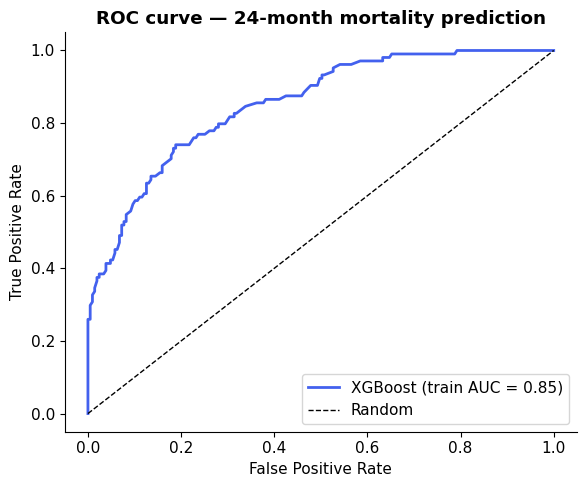

In [79]:
model = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1,
                      eval_metric='logloss', random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')

print(f"AUC per fold: {[f'{s:.3f}' for s in auc_scores]}")
print(f"Mean AUC: {auc_scores.mean():.3f} (+/- {auc_scores.std():.3f})")

# ROC curve on full dataset (for visualisation only)
model.fit(X, y)
y_prob = model.predict_proba(X)[:, 1]
fpr, tpr, _ = roc_curve(y, y_prob)
auc_full = roc_auc_score(y, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#4361EE', lw=2, label=f'XGBoost (train AUC = {auc_full:.2f})')
ax.plot([0,1], [0,1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curve — 24-month mortality prediction', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

- **CV AUC = 0.586**: better than random (0.5) but below the clinical usefulness threshold (~0.65)

This is expected: only 5 features, 3 of which are binary mutation flags, and ~400 patients is small for ML. The Cox model (concordance = 0.685) actually outperforms XGBoost here because it uses the full survival time information rather than reducing it to a binary 24-month outcome.

**Takeaway**: mutation flags alone aren't sufficient for strong mortality prediction. Stage dominates. SHAP below will show exactly how much each feature contributes

## 5. SHAP — what drives the predictions?

AUC tells us how well the model predicts, but not why, SHAP (Shapley additive explanations) breaks down each prediction into the contribution of each feature.

For each patient: `prediction = baseline + SHAP(KRAS) + SHAP(STK11) + SHAP(AGE) + ...`

A positive SHAP value pushes the prediction toward death, negative pushes it toward survival.

The **beeswarm plot** shows the distribution across all patients:
- Each dot = one patient
- X axis = SHAP value (impact on prediction)
- Color = feature value (red = high, blue = low)

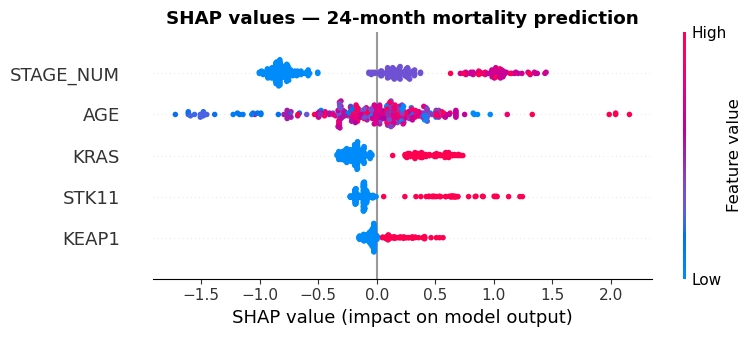

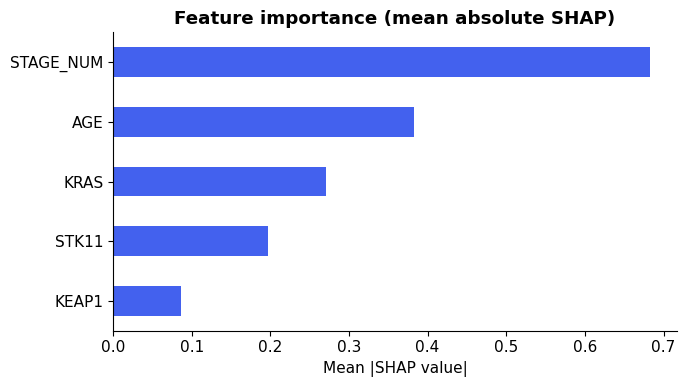

In [80]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# Beeswarm plot
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X, show=False)
plt.title('SHAP values — 24-month mortality prediction', fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# Mean absolute SHAP per feature (cleaner for a quick ranking)
mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
mean_shap.plot(kind='barh', ax=ax, color='#4361EE')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature importance (mean absolute SHAP)', fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**STAGE_NUM**: high stage (red) pushes right, low stage (blue) pushes left. Consistent with Cox

**AGE**: second most important for XGBoost but not significant in Cox. XGBoost picks up non-linear age effects that the linear Cox model misses

**KRAS**: two clear clusters (mutated vs wild-type) with moderate effect. Ranked higher here than in Cox, likely because XGBoost captures its interaction with STK11, which Cox misses without an explicit interaction term

**STK11**: mutated patients (red) push right toward death. Consistent with Cox (p=0.002)

**KEAP1**: almost everything clustered near 0. Minimal impact on predictions, consistent with Cox (p=0.81)

**Main findings:**
1. Tumour stage is by far the strongest predictor of 24-month mortality
2. STK11 co-mutation with KRAS significantly worsens survival (HR ~1.9), independent of stage and age
3. KEAP1 shows no significant independent prognostic value in this cohort (may be underpowered)
4. Cox outperforms XGBoost here because it uses full survival time information rather than a binary 24-month cutoff

**Answer to the main question**: Do KRAS co-mutation subtypes (with STK11 or KEAP1) show significantly worse survival than KRAS alone?

Yes for KRAS+STK11 (HR=1.90, p=0.002 in Cox, visible separation in KM curves). No clear evidence for KRAS+KEAP1, the group may be too small (n=36) to reach significance in this cohort

**Limitation**: the Cox model tests mutation effects independently. To properly test KRAS+STK11 as a co-mutation, interaction terms would be needed.